In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [35]:
Sensors = ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'FIT601',
           'AIT201', 'AIT202', 'AIT203', 'AIT401', 'AIT402', 'AIT501', 'AIT502', 'AIT503', 'AIT504',
           'LIT101', 'LIT301', 'LIT401',
           'PIT501', 'PIT502', 'PIT503',
           'DPIT301']

In [36]:
stage_map = [[['FIT101', 'LIT101'], ['MV101', 'P101', 'P102']],
             [['AIT201', 'AIT202', 'AIT203', 'FIT201'], ['MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206']],
             [['DPIT301', 'FIT301', 'LIT301'], ['MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302']],
             [['AIT401', 'AIT402', 'FIT401', 'LIT401'], ['P401', 'P402', 'P403', 'P404', 'UV401']],
             [['AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503'], ['P501', 'P502']],
             [['FIT601'], ['P601', 'P602', 'P603']]]

In [37]:
def bound(df, num):
    print(f"min = {df.min()}, max = {df.max()}")
    mu = np.mean(df)
    sigma = np.std(df)
    # print(f"mu = {mu}, sigma = {sigma}")
    LL = mu - num * sigma
    HH = mu + num * sigma
        
    return round(float(LL), 4), round(float(HH), 4)

In [38]:
def plot_analysis(df, device, LL, HH):
    plt.figure(figsize=(25, 6))
    
    # 1. 繪製原始流量數據
    plt.plot(df['Timestamp'], df[device], color='steelblue', alpha=0.5, label=f'{device} Flow', linewidth=1.5)
    
    # 2. 標註自動計算的門檻線
    # 畫出基礎門檻 (Base Threshold)
    # plt.axhline(y=base_th, color='gray', linestyle='--', alpha=0.8, label=f'Base Threshold ({base_th:.2f})')
    
    # 畫出 3-sigma 的上下限 (LL & HH)
    plt.axhline(y=LL, color='red', linestyle='-', linewidth=1.5, label=f'Lower Limit (LL: {LL:.4f})')
    plt.axhline(y=HH, color='red', linestyle='-', linewidth=1.5, label=f'Upper Limit (HH: {HH:.4f})')
    
    # 3. 繪製穩定運作區間的陰影層 (State 3)
    plt.axhspan(LL, HH, color='green', alpha=0.15, label='Steady State Range')
    
    # 4. 加上標題與標籤
    plt.title(f'{device} Automated Threshold Analysis (K-Means + 3-Sigma)', fontsize=14)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Flow Value', fontsize=12)
    
    # 優化圖例顯示
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

#### FIT（流量計）

(495000, 54)
(424799, 54)
min = 1.279826, max = 2.745092
'LL': 2.3258, 'HH': 2.7576


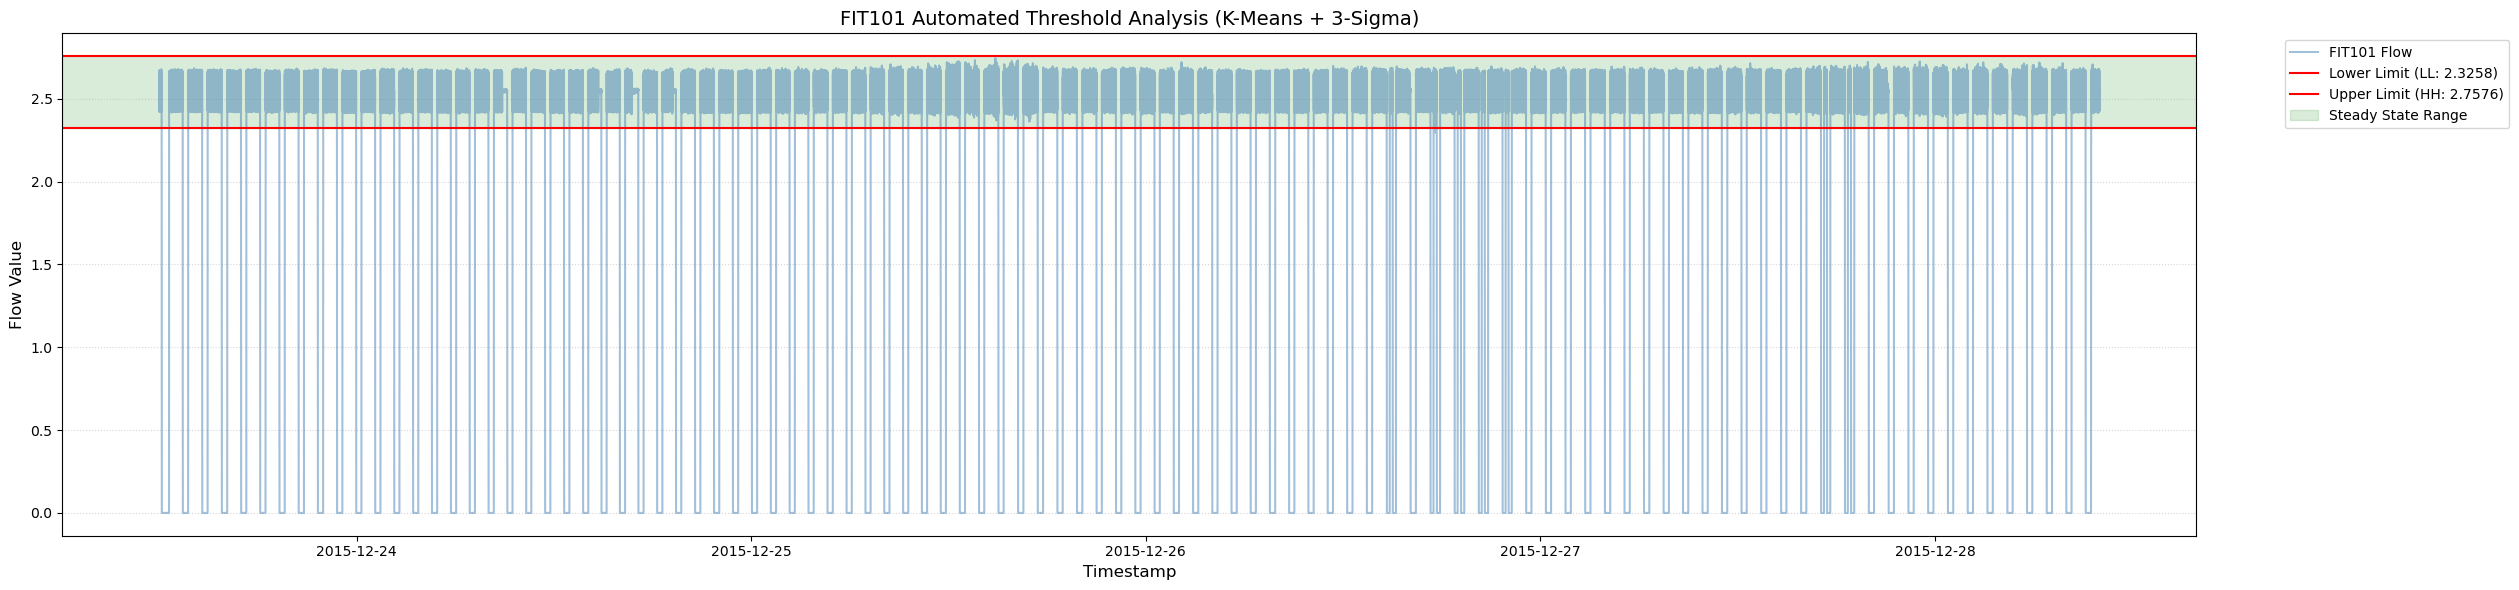

min = 1.226668, max = 2.48781
'LL': 2.3924, 'HH': 2.4973


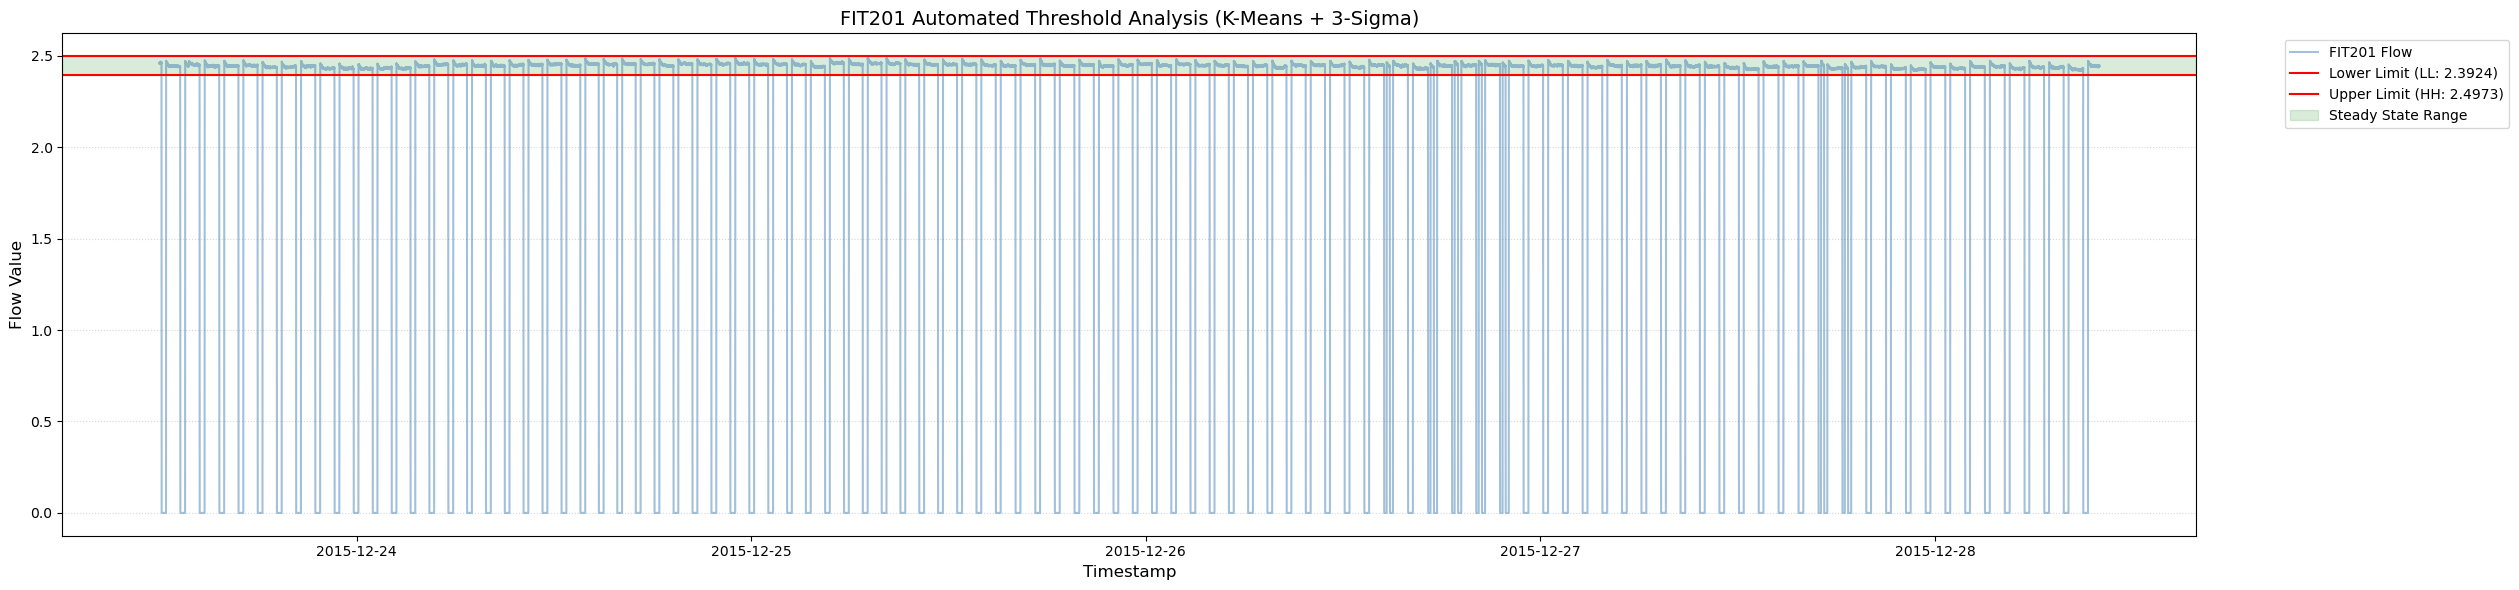

min = 1.131986, max = 2.358774
'LL': 2.0544, 'HH': 2.375


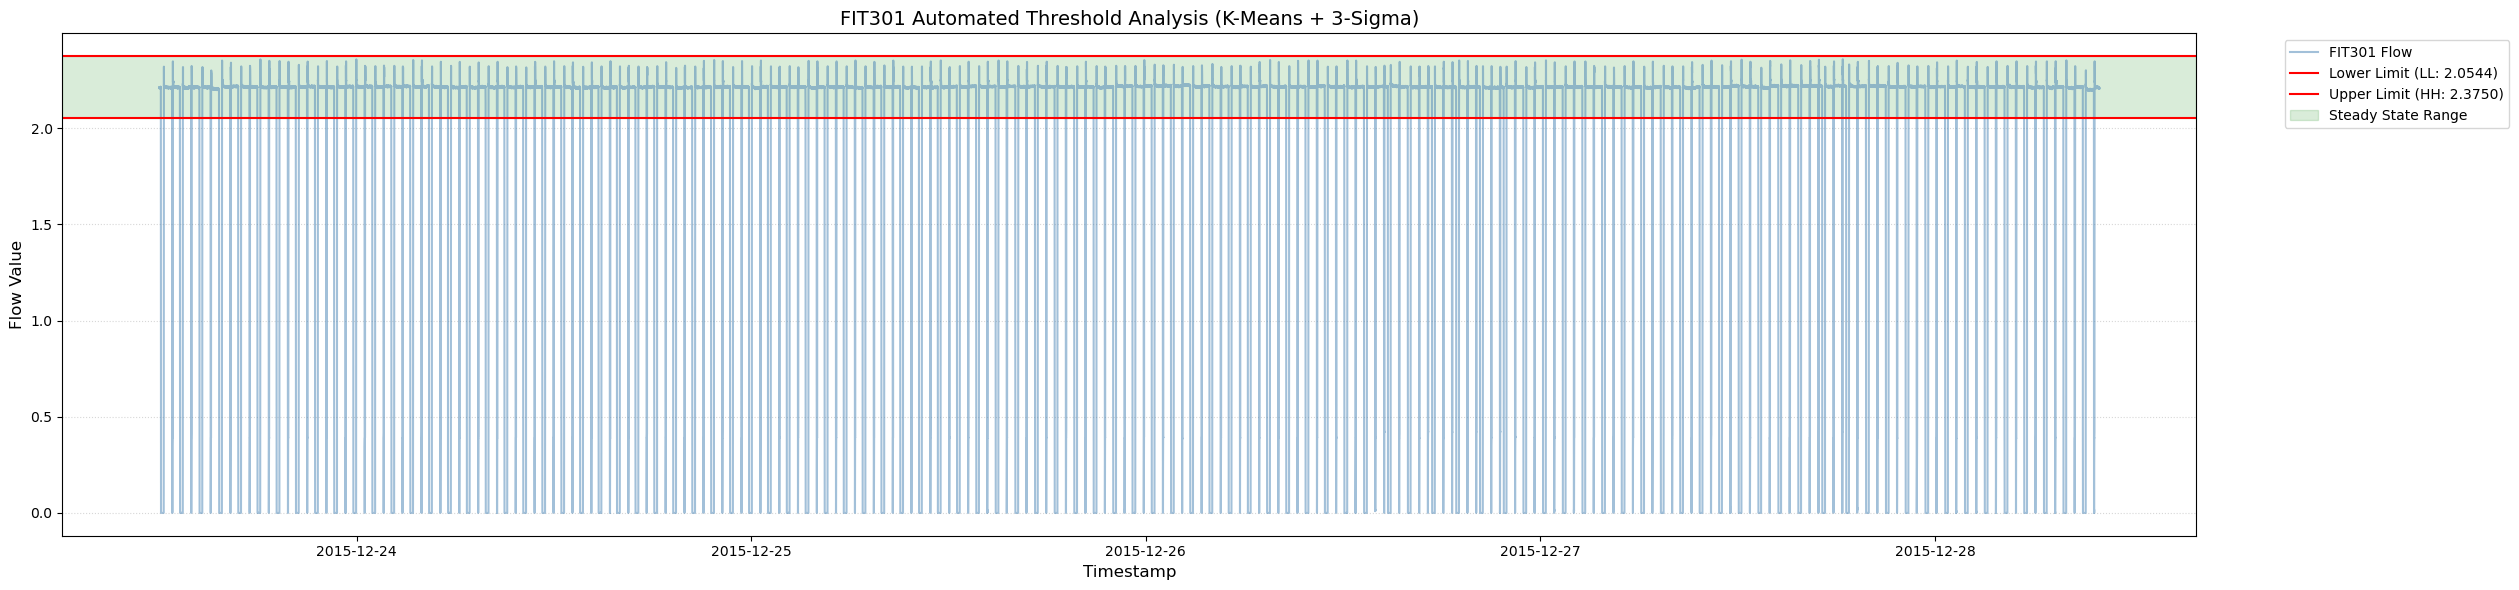

'LL': 0, 'HH': 1.75


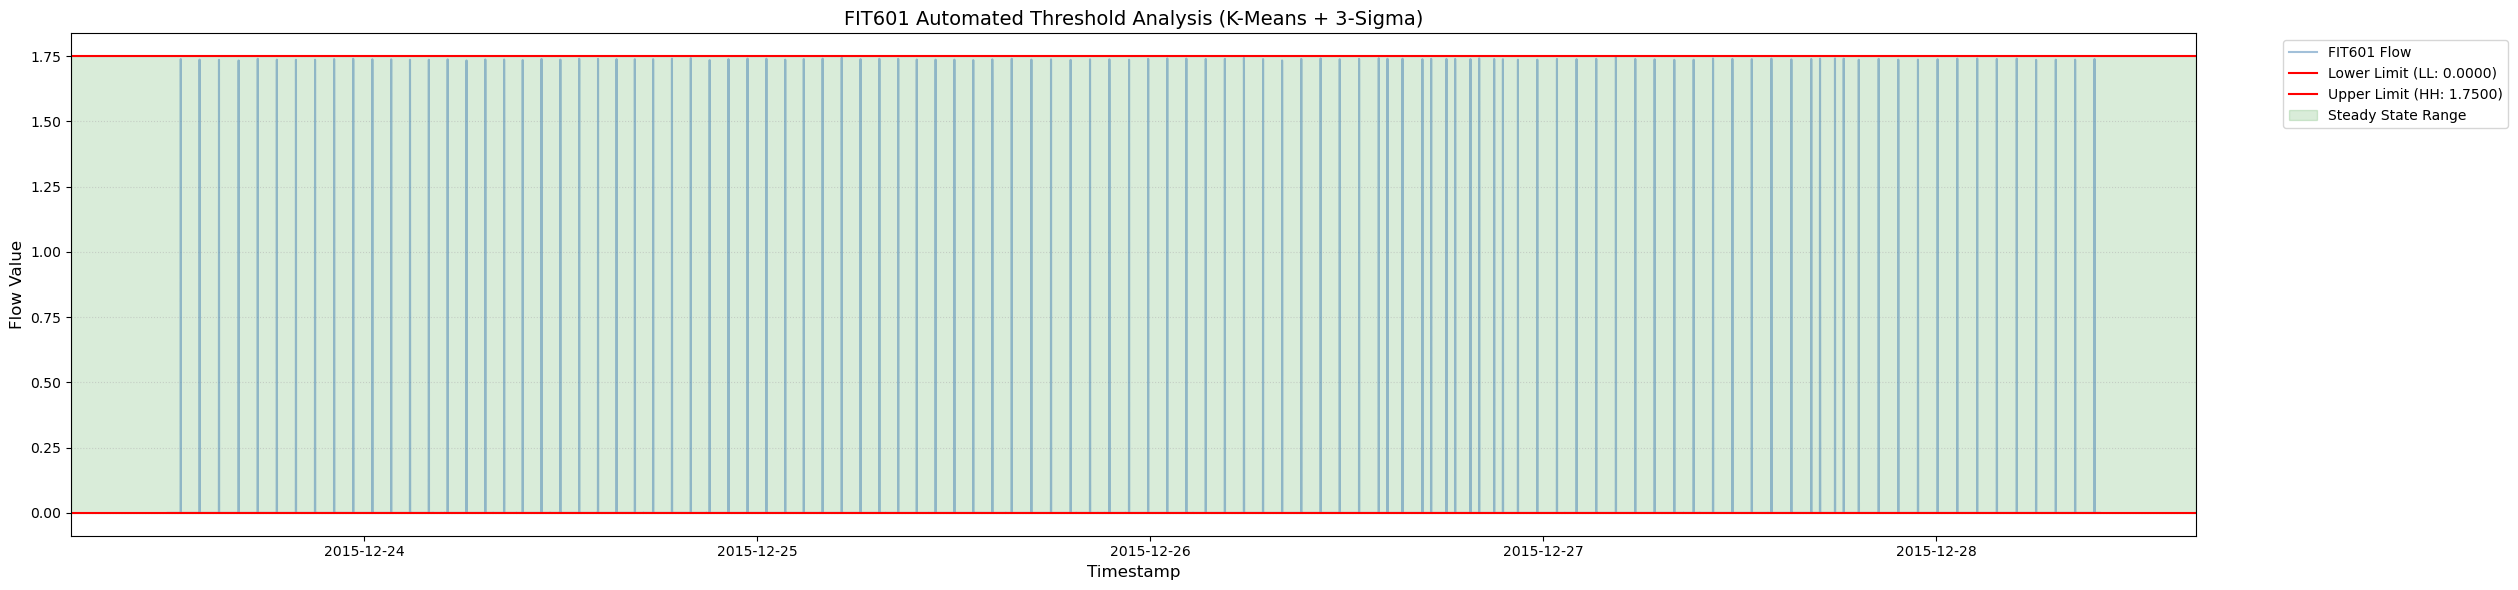

In [39]:
df_Normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
df_Attack = pd.read_parquet("../Dataset/SWaT_Dataset_Attack_v1.parquet")

print(df_Normal.shape)

start_time = pd.to_datetime('2015-12-23 12:00:00')
df = df_Normal[df_Normal["Timestamp"] > start_time]
print(df.shape)

for device in Sensors:
    if device == 'FIT101':
        num = 2.5
        X = df[device].values.reshape(-1, 1)

        kmeans = KMeans(n_clusters=2, n_init=10).fit(X)
        centers = sorted(kmeans.cluster_centers_.flatten())

        base_threshold = sum(centers) / 2

        steady_state_data = df[df[device] > base_threshold][device]

        LL, HH = bound(steady_state_data, num)
        
        print(f"'LL': {LL}, 'HH': {HH}")
        
        plot_analysis(df, device, LL, HH)
        
    elif device == 'FIT201':
        num = 1.5
        X = df[device].values.reshape(-1, 1)

        kmeans = KMeans(n_clusters=2, n_init=10).fit(X)
        centers = sorted(kmeans.cluster_centers_.flatten())

        base_threshold = sum(centers) / 2

        steady_state_data = df[df[device] > base_threshold][device]

        LL, HH = bound(steady_state_data, num)
        
        print(f"'LL': {LL}, 'HH': {HH}")
        
        plot_analysis(df, device, LL, HH)
    
    elif device == 'FIT301':
        num = 4
        X = df[device].values.reshape(-1, 1)
        kmeans = KMeans(n_clusters=2, n_init=10).fit(X)
        centers = sorted(kmeans.cluster_centers_.flatten())
        base_threshold = sum(centers) / 2
        steady_state_data = df[df[device] > base_threshold][device]
        LL, HH = bound(steady_state_data, num)       
        print(f"'LL': {LL}, 'HH': {HH}")  
        plot_analysis(df, device, LL, HH)
    
    elif device == 'FIT601':
        LL = 0
        HH = 1.75
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)
            


(495000, 54)
(424799, 54)
min = 1.672636, max = 1.747862
'LL': 1.6721, 'HH': 1.7517


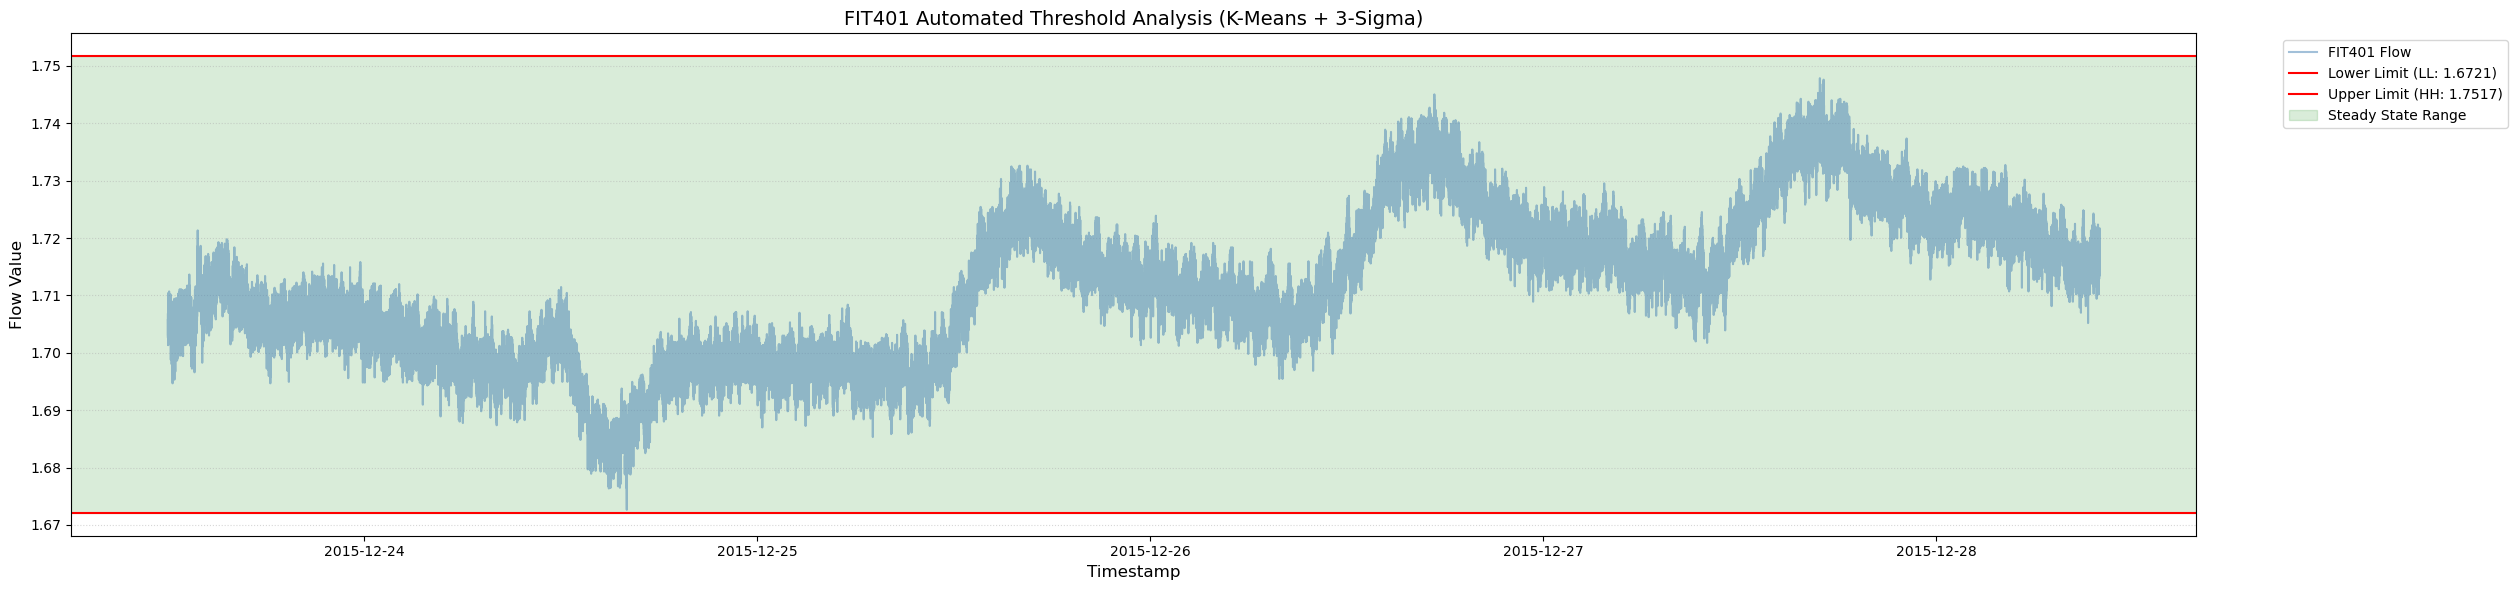

min = 1.685081, max = 1.757754
'LL': 1.6834, 'HH': 1.7606


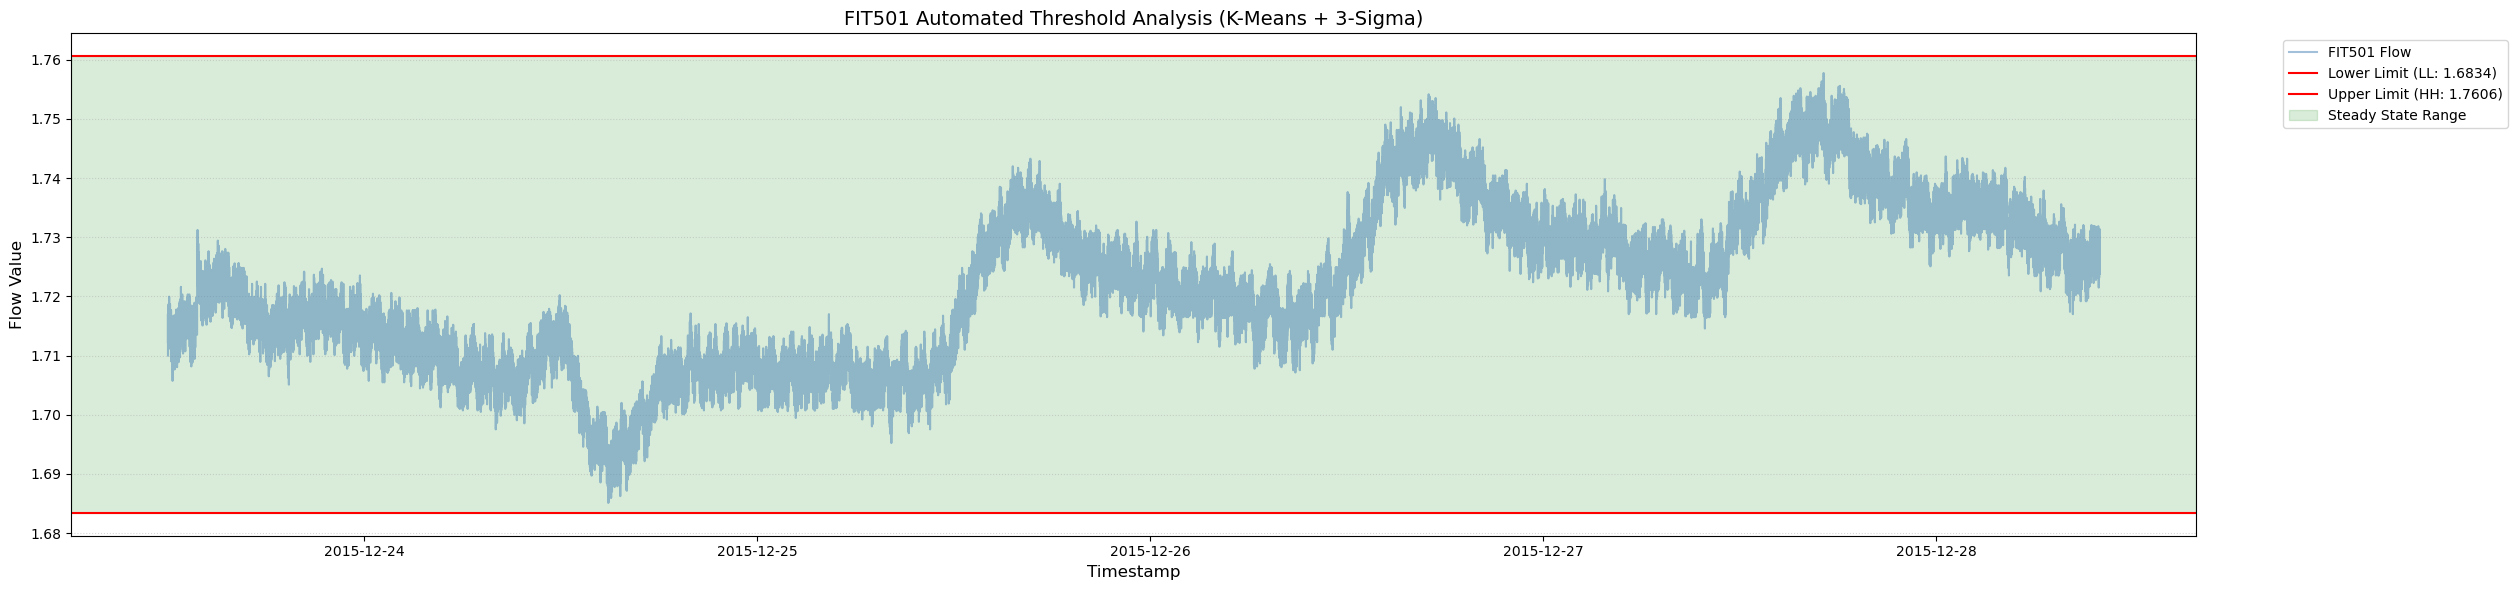

min = 1.194057, max = 1.361983
'LL': 1.1928, 'HH': 1.3644


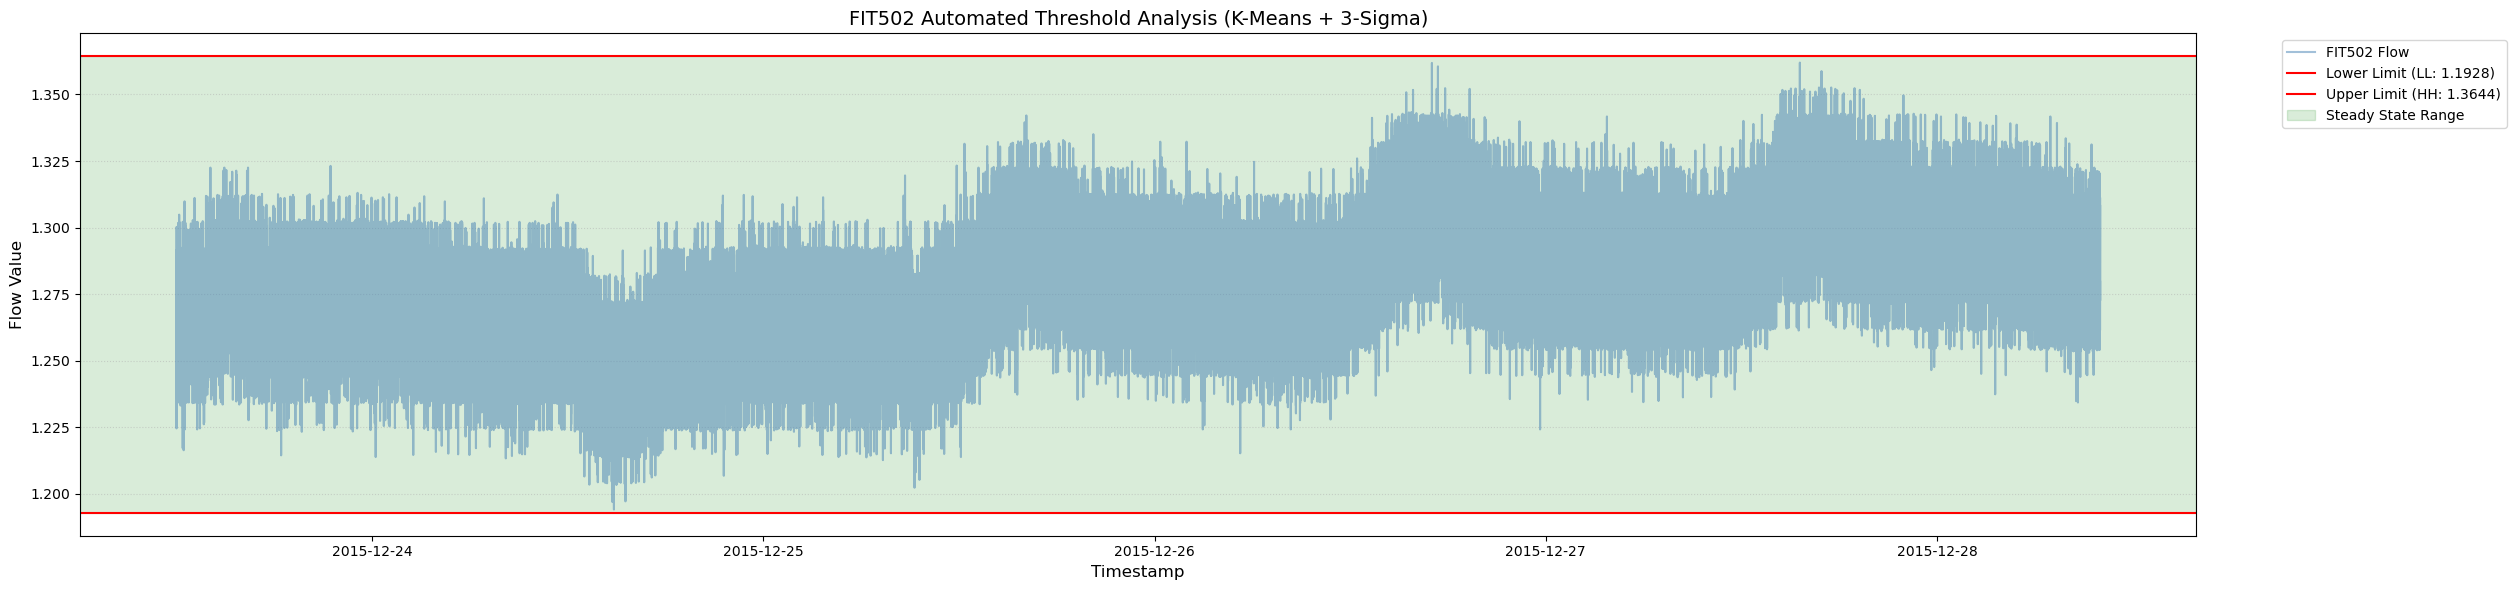

min = 0.7251545, max = 0.7521685
'LL': 0.7229, 'HH': 0.7526


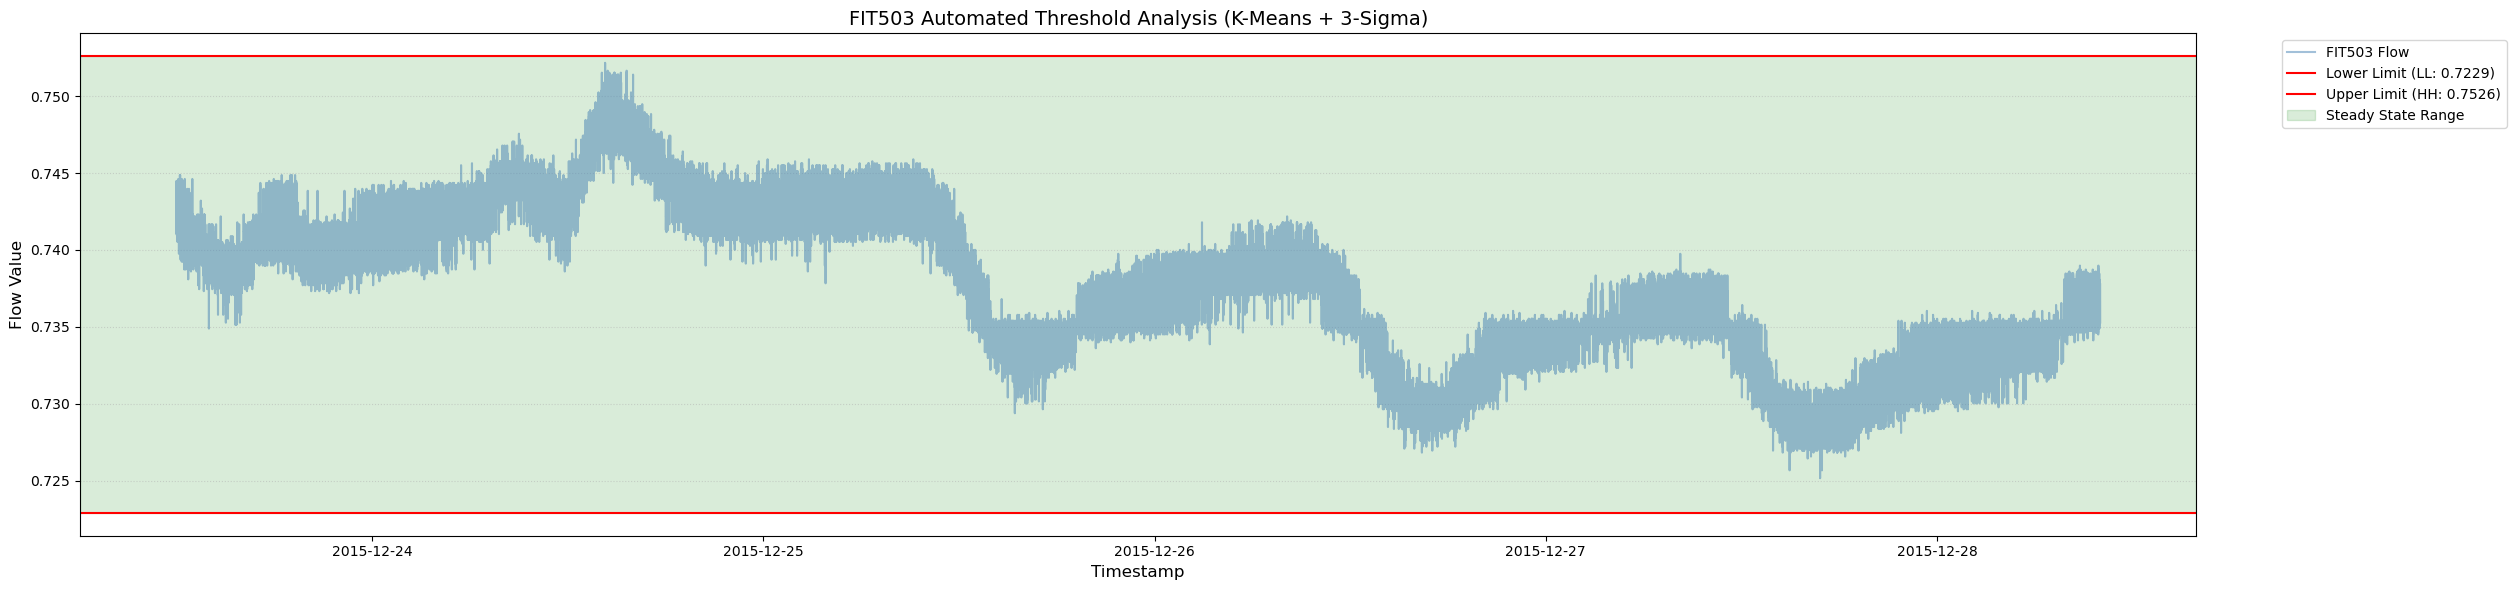

min = 0.3017007, max = 0.3138712
'LL': 0.3014, 'HH': 0.3145


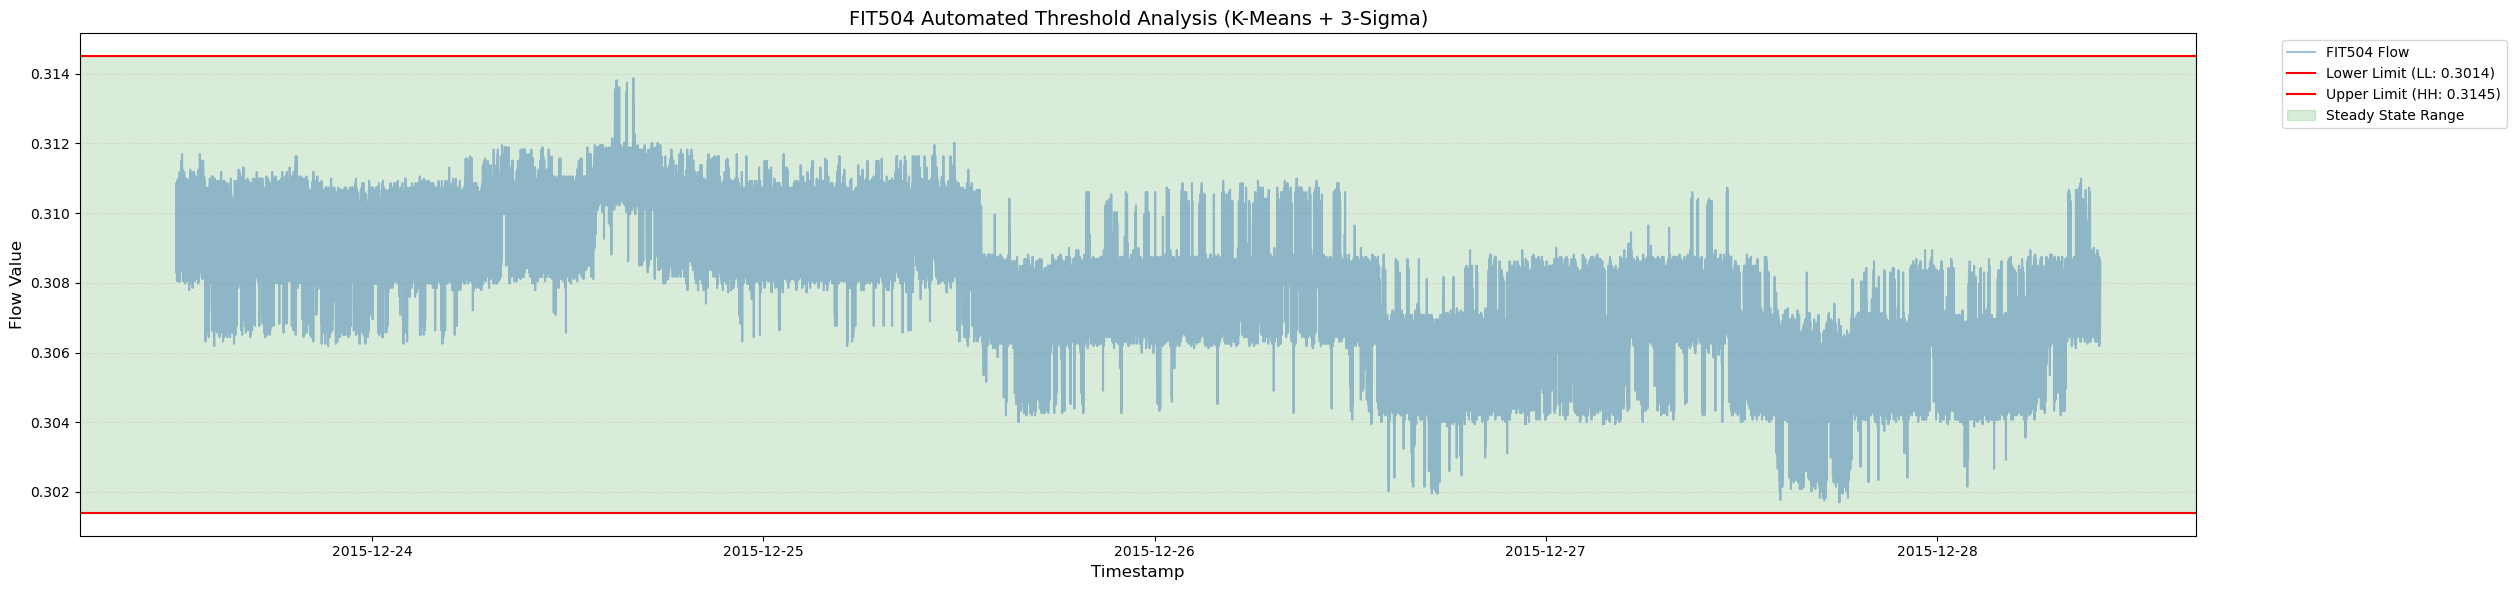

In [40]:
df_Normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
print(df_Normal.shape)

start_time = pd.to_datetime('2015-12-23 12:00:00')
df = df_Normal[df_Normal["Timestamp"] > start_time]
print(df.shape)

# df_normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
# df_attack = pd.read_parquet("../Dataset/SWaT_Dataset_Attack_v1.parquet")
# df_plot = pd.concat([df_normal, df_attack], ignore_index=True)
# df_plot = df_plot[df_plot["Timestamp"] > start_time]

for device in Sensors:
    if device == 'FIT401': 
        num = 3.1
        LL, HH = bound(df[device], num)
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)
        
    elif device == 'FIT501': 
        num = 2.9
        LL, HH = bound(df[device], num)
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)
        
    elif device == 'FIT502': 
        num = 4.1
        LL, HH = bound(df[device], num)
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)
    
    elif device == 'FIT503': 
        num = 3
        LL, HH = bound(df[device], num)
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)
    
    elif device == 'FIT504': 
        num = 3.5
        LL, HH = bound(df[device], num)
        print(f"'LL': {LL}, 'HH': {HH}")
        plot_analysis(df, device, LL, HH)

### LIT（水位計）

(495000, 54)
(424799, 54)
LL = 500, HH = 800


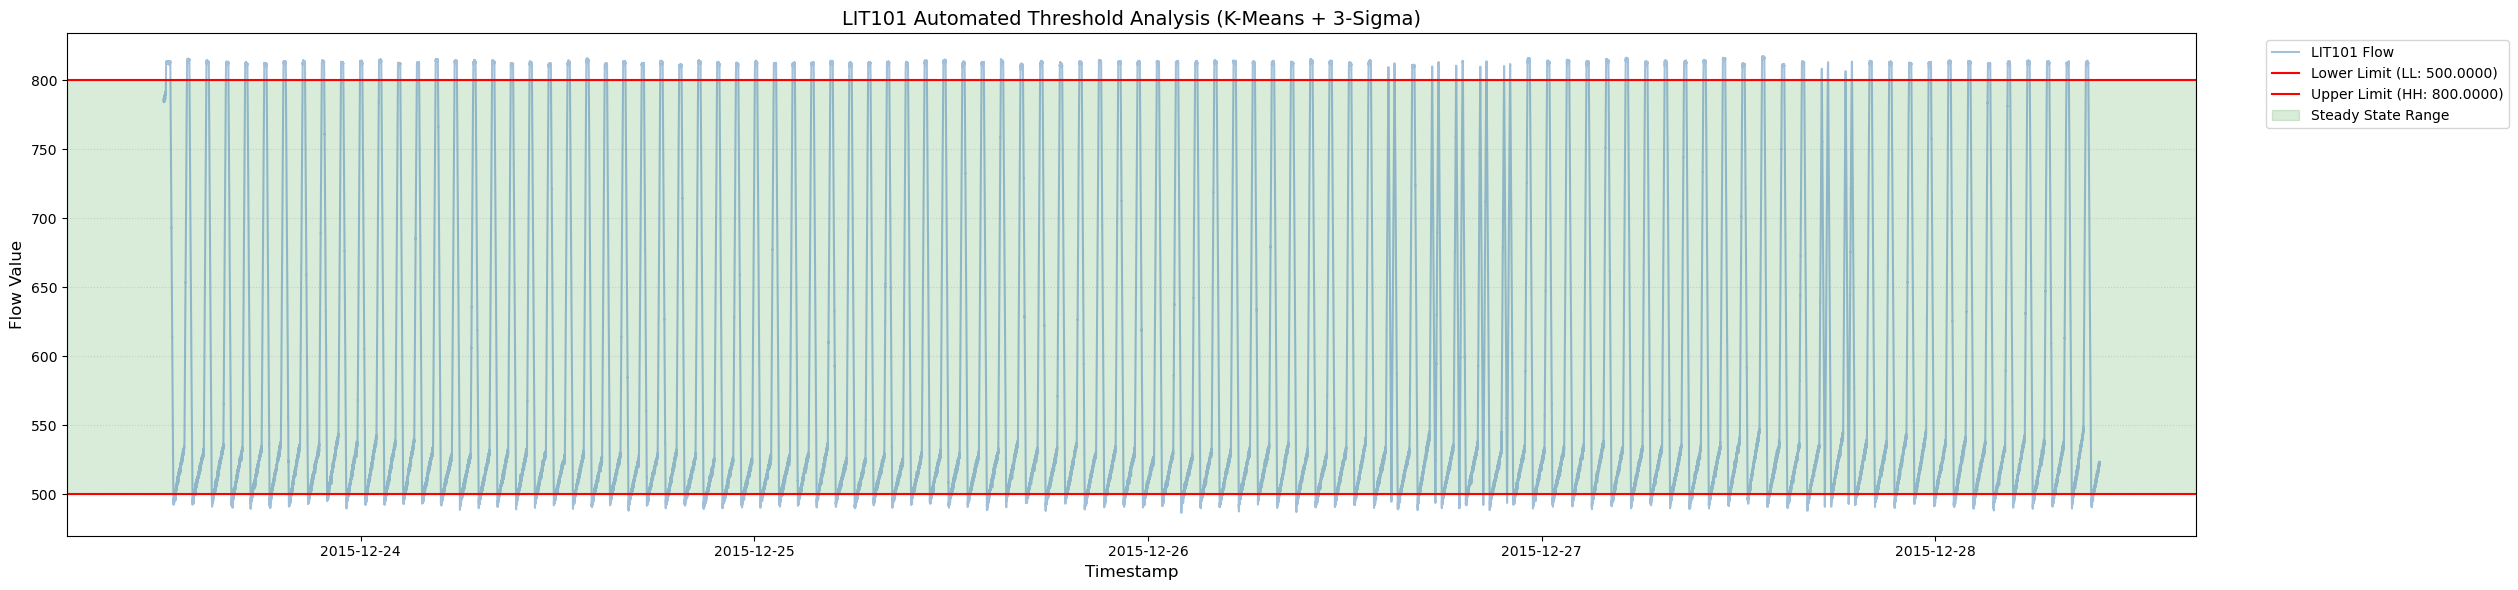

LL = 800, HH = 1000


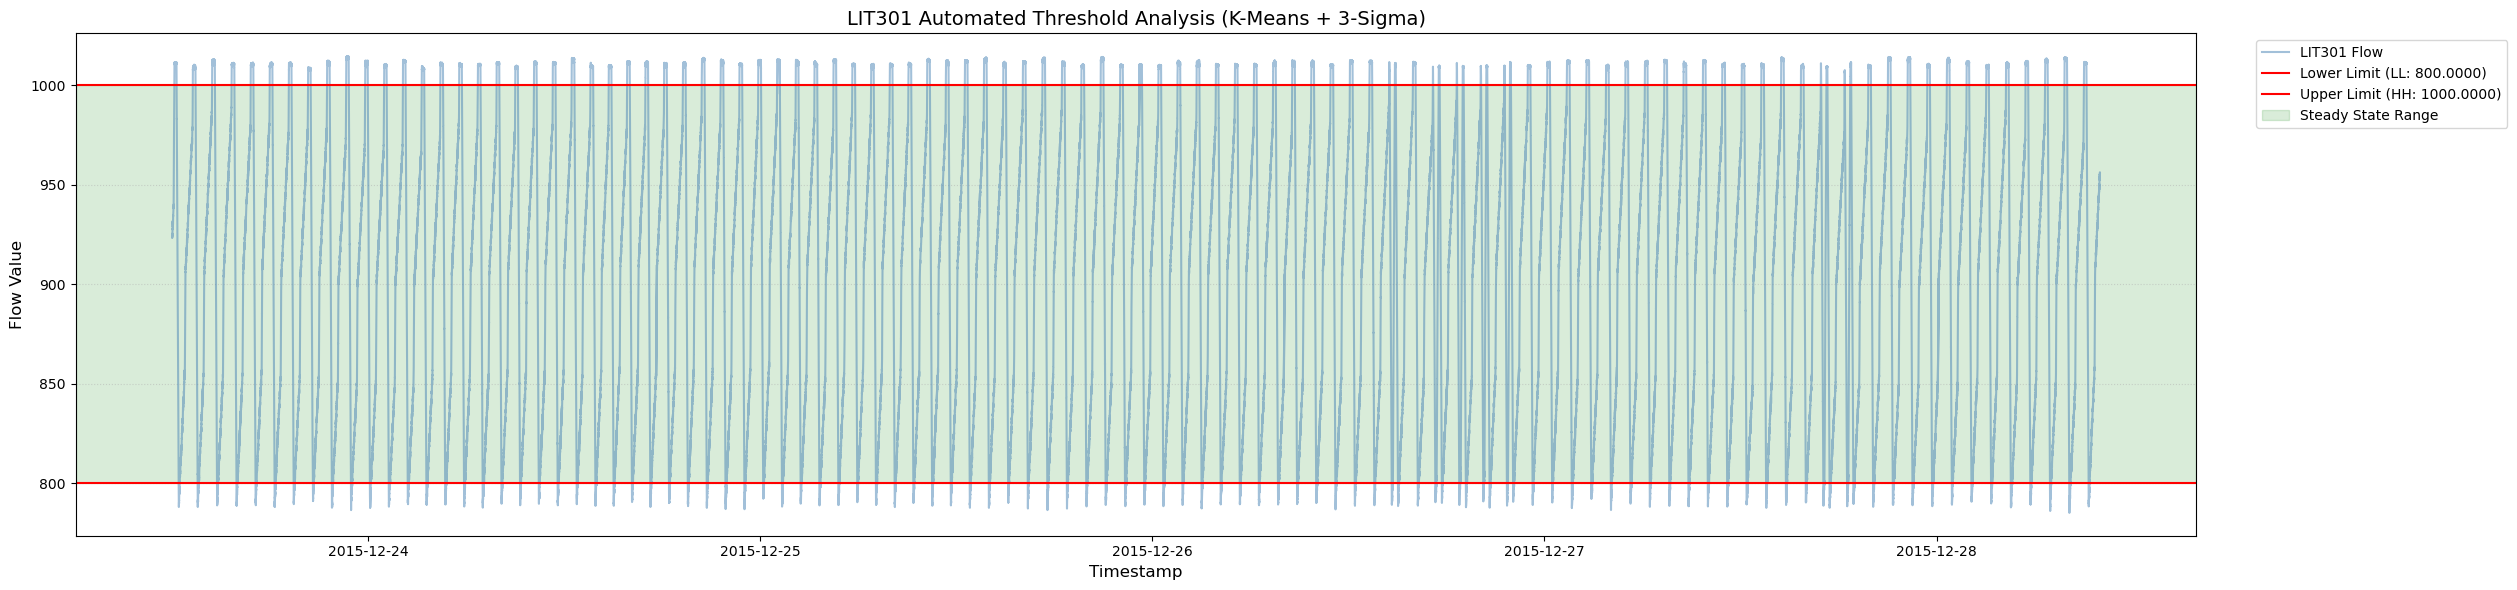

LL = 800, HH = 1000


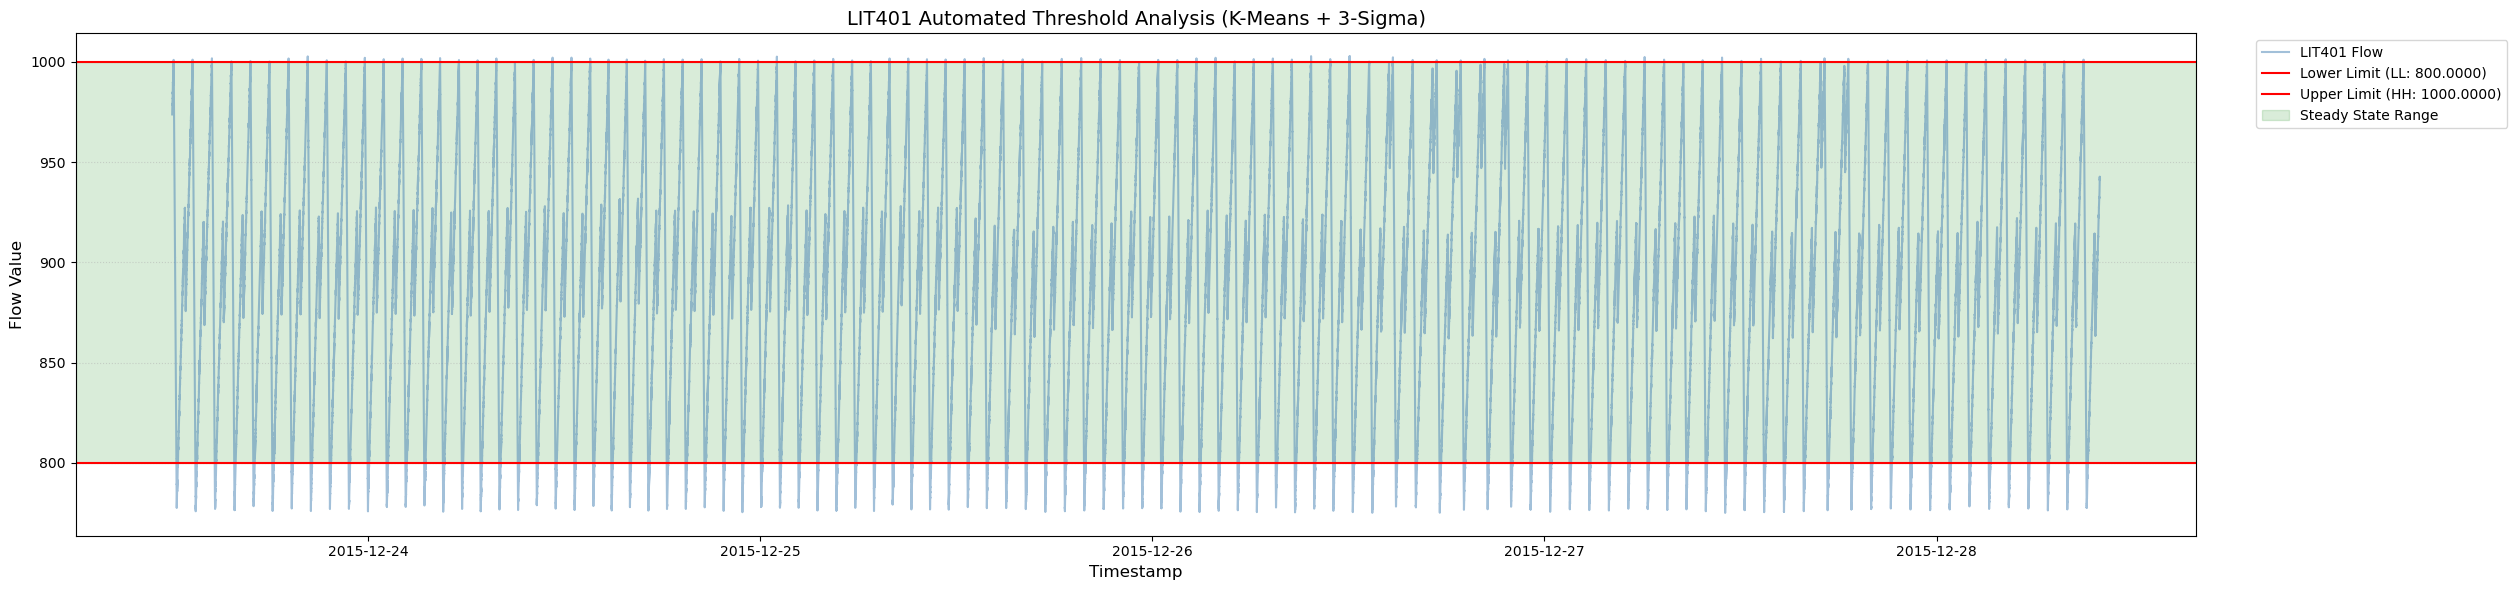

In [41]:
df_Normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
print(df_Normal.shape)

start_time = pd.to_datetime('2015-12-23 12:00:00')
df = df_Normal[df_Normal["Timestamp"] > start_time]
print(df.shape)

for device in Sensors:
    if device == 'LIT101':
        LL = 500
        HH = 800
        
        print(f"LL = {LL}, HH = {HH}")
        
        plot_analysis(df, device, LL, HH)
    
    elif device == 'LIT301':
        LL = 800
        HH = 1000
        
        print(f"LL = {LL}, HH = {HH}")
        
        plot_analysis(df, device, LL, HH)
    
    elif device == 'LIT401':
        LL = 800
        HH = 1000
        
        print(f"LL = {LL}, HH = {HH}")
        
        plot_analysis(df, device, LL, HH)
    

### AIT（水質分析）

In [42]:
# df_Normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
# print(df_Normal.shape)

# start_time = pd.to_datetime('2015-12-23 12:00:00')
# df = df_Normal[df_Normal["Timestamp"] > start_time]
# print(df.shape)

df_normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
df_atttack = pd.read_parquet("../Dataset/SWaT_Dataset_Attack_v1.parquet")
df = pd.concat([df_normal, df_atttack], ignore_index=True)

# 'AIT201', 'AIT202', 'AIT203', 'AIT401', 'AIT402', 'AIT501', 'AIT502', 'AIT503', 'AIT504',

for device in Sensors:
    if device == 'AIT201':
        LL = 250
        HH = 275
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT202':
        LL = 8.3
        HH = 8.475
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT203':
        LL = 310
        HH = 345
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT401':
        LL = df['AIT401'].max()
        HH = df['AIT401'].max()
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT402':
        LL = 150
        HH = 192
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT501':
        LL = 7.80
        HH = 7.93
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT502':
        LL = 140
        HH = 180
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT503':
        LL = 250
        HH = 285
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'AIT504':
        LL = 10 # 9.99
        HH = 14
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    

'LL': 250, 'HH': 275
'LL': 8.3, 'HH': 8.475
'LL': 310, 'HH': 345
'LL': 148.8561, 'HH': 148.8561
'LL': 150, 'HH': 192
'LL': 7.8, 'HH': 7.93
'LL': 140, 'HH': 180
'LL': 250, 'HH': 285
'LL': 10, 'HH': 14


### PIT(壓力計)、DPIT(壓差計)

In [43]:
# df_Normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
# print(df_Normal.shape)

# start_time = pd.to_datetime('2015-12-23 12:00:00')
# df = df_Normal[df_Normal["Timestamp"] > start_time]
# print(df.shape)

df_normal = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
df_atttack = pd.read_parquet("../Dataset/SWaT_Dataset_Attack_v1.parquet")
df = pd.concat([df_normal, df_atttack], ignore_index=True)

for device in Sensors:
    if device == 'PIT501':
        LL = 245
        HH = 260.5
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'PIT502':
        LL = 0.8
        HH = 1.9
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'PIT503':
        LL = 184.5
        HH = 198.5
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    
    elif device == 'DPIT301':
        LL = 0
        HH = 21
        print(f"'LL': {LL}, 'HH': {HH}")
        # plot_analysis(df, device, LL, HH)
    

'LL': 245, 'HH': 260.5
'LL': 0.8, 'HH': 1.9
'LL': 184.5, 'HH': 198.5
'LL': 0, 'HH': 21


### Convert to Binary

In [ ]:
Threshold = {
    # Stage 1: Raw Water Storage
    'FIT101': {'min': 0, 'LL': 2.3258, 'HH': 2.7576},  # Flow to raw water tank
    'LIT101': {'LL': 500, 'HH': 800},  # Raw water tank level
    'MV101':  {'0': 'Closed', '1': 'Open', '2': 'Transition'}, # Controls flow to tank[cite: 1]
    'P101':   {'1': 'Off', '2': 'On'},    # Pumps to Stage 2[cite: 1]
    'P102':   {'1': 'Off', '2': 'On'},    # Backup pump[cite: 1]

    # Stage 2: Pre-Treatment (Chemical Dosing)
    'AIT201': {'LL': 250, 'HH': 275},  # NaCl level (Conductivity)[cite: 1]
    'AIT202': {'LL': 8.3, 'HH': 8.475},  # HCl level (pH)[cite: 1]
    'AIT203': {'LL': 310, 'HH': 345},  # NaOCl level (ORP)[cite: 1]
    'FIT201': {'min': 0, 'LL': 2.3924, 'HH': 2.4973},  # Dosing flow[cite: 1]
    'MV201':  {'0': 'Closed', '1': 'Open', '2': 'Transition'},
    'P201':   {'1': 'Off', '2': 'On'},    # NaCl dosing[cite: 1]
    'P202':   {'1': 'Off', '2': 'On'},
    'P203':   {'1': 'Off', '2': 'On'},    # HCl dosing[cite: 1]
    'P204':   {'1': 'Off', '2': 'On'},
    'P205':   {'1': 'Off', '2': 'On'},    # NaOCl dosing[cite: 1]
    'P206':   {'1': 'Off', '2': 'On'},

    # Stage 3: Ultrafiltration (UF)
    'DPIT301': {'LL': 0, 'HH': 21}, # UF differential pressure[cite: 1]
    'FIT301':  {'min': 0, 'LL': 2.0544, 'HH': 2.375}, # UF flow[cite: 1]
    'LIT301':  {'LL': 800, 'HH': 1000}, # UF feed tank level[cite: 1]
    'MV301':   {'0': 'Closed', '1': 'Open', '2': 'Transition'}, # Backwash control[cite: 1]
    'MV302':   {'0': 'Closed', '1': 'Open', '2': 'Transition'}, # To De-chlorination[cite: 1]
    'MV303':   {'0': 'Closed', '1': 'Open', '2': 'Transition'}, # Backwash drain[cite: 1]
    'MV304':   {'0': 'Closed', '1': 'Open', '2': 'Transition'}, # UF drain[cite: 1]
    'P301':    {'1': 'Off', '2': 'On'},    # UF feed pump[cite: 1]
    'P302':    {'1': 'Off', '2': 'On'},

    # Stage 4: De-Chlorination & UV
    'AIT401': {'LL': 148.8561, 'HH': 148.8561},  # RO hardness[cite: 1]
    'AIT402': {'LL': 150, 'HH': 192},  # ORP for NaHSO3 dosing[cite: 1]
    'FIT401': {'LL': 1.6721, 'HH': 1.7517},  # UV dechlorinator flow[cite: 1]
    'LIT401': {'LL': 800, 'HH': 1000},  # RO feed tank level[cite: 1]
    'P401':   {'1': 'Off', '2': 'On'},    # RO feed pump[cite: 1]
    'P402':   {'1': 'Off', '2': 'On'},
    'P403':   {'1': 'Off', '2': 'On'},    # NaHSO3 pump[cite: 1]
    'P404':   {'1': 'Off', '2': 'On'},
    'UV401':  {'1': 'Off', '2': 'On'}, # State is always on.

    # Stage 5: Reverse Osmosis (RO)
    'AIT501': {'LL': 7.8, 'HH': 7.93},  # RO pH[cite: 1]
    'AIT502': {'LL': 140, 'HH': 180},  # RO ORP[cite: 1]
    'AIT503': {'LL': 250, 'HH': 285},  # RO feed conductivity[cite: 1]
    'AIT504': {'LL': 10, 'HH': 14},  # RO permeate conductivity[cite: 1]
    'FIT501': {'LL': 1.6721, 'HH': 1.7517},  # RO inlet flow[cite: 1]
    'FIT502': {'LL': 1.6834, 'HH': 1.7606},  # RO permeate flow[cite: 1]
    'FIT503': {'LL': 1.1928, 'HH': 1.3644},  # RO reject flow[cite: 1]
    'FIT504': {'LL': 0.7229, 'HH': 0.7526},  # RO recirculation flow[cite: 1]
    'PIT501': {'LL': 245, 'HH': 260.5},  # RO feed pressure[cite: 1]
    'PIT502': {'LL': 0.8, 'HH': 1.9},  # RO permeate pressure[cite: 1]
    'PIT503': {'LL': 184.5, 'HH': 198.5},  # RO reject pressure[cite: 1]
    'P501':   {'1': 'Off', '2': 'On'},    # RO pump[cite: 1]
    'P502':   {'1': 'Off', '2': 'On'},

    # Stage 6: UF Backwash & Recycling
    'FIT601': {'min': 0, 'LL': 0.3014, 'HH': 0.3145},  # UF backwash flow[cite: 1]
    'P601':   {'1': 'Off', '2': 'On'},    # Recycling pump (Permeate to Raw)[cite: 1]
    'P602':   {'1': 'Off', '2': 'On'},    # UF backwash pump[cite: 1]
    'P603':   {'1': 'Off', '2': 'On'}     # Backup/Not implemented[cite: 1]
}

In [47]:
def binarization_module(df, thresholds):
    df_binary = []
    row = df.loc[0]
    
    # print(df.columns.drop(['index', 'Timestamp', 'Label', 'Detailed_Label']))
    
    for col in df.columns.drop(['Timestamp', 'Label', 'Detailed_Label']):
        print(col)
        if col not in thresholds:
            print(f"{col} None!")
            break
            
        rule = thresholds[col]
        
        
        if col[:3] == 'FIT':
            if row[col] == 0:
                df_binary.append([1, 0, 0, 0])
            elif row[col] < rule['LL']:
                df_binary.append([0, 1, 0, 0])
            elif row[col] >= rule['LL'] and row[col] <= rule['HH']:
                df_binary.append([0, 0, 1, 0])
            elif row[col] > rule['HH']:
                df_binary.append([0, 0, 0, 1])
            else:
                print("Out of range!")
                        
        elif col[:3] == 'LIT' or col[:3] == 'AIT' or col[:3] == 'DIT' or col[:4] == 'DPIT': 
            if row[col] < rule['LL']:
                df_binary.append([1, 0, 0])
            elif row[col] >= rule['LL'] and row[col] <= rule['HH']:
                df_binary.append([0, 1, 0])
            elif row[col] > rule['HH']:
                df_binary.append([0, 0, 1])
            else:
                print("Out of range!")
                
        elif col[:2] == 'MV':
            if row[col] == 0:
                df_binary.append([1, 0, 0])
            elif row[col] == 1:
                df_binary.append([0, 1, 0])
            elif row[col] == 2:
                df_binary.append([0, 0, 1])
            else:
                print("Out of range!")
        
        elif col[:1] == 'P' or col[:2] == 'UV':
            if row[col] == 1:
                df_binary.append([1, 0])
            elif row[col] == 2:
                df_binary.append([0, 1])
            else:
                print("Out of range!")
        else:           
            print("Out of range!")
                           
    return df_binary

df = pd.read_parquet("../Dataset/SWaT_Dataset_Normal_v1.parquet")
df_binary = binarization_module(df, Threshold)

print(df_binary)

FIT101
LIT101
MV101
P101
P102
AIT201
AIT202
AIT203
FIT201
MV201
P201
P202
P203
P204
P205
P206
DPIT301
FIT301
LIT301
MV301
MV302
MV303
MV304
P301
P302
AIT401
AIT402
FIT401
LIT401
P401
P402
P403
P404
UV401
AIT501
AIT502
AIT503
AIT504
FIT501
FIT502
FIT503
FIT504
P501
P502
PIT501
Out of range!
PIT502
Out of range!
PIT503
Out of range!
FIT601
P601
P602
P603
[[1, 0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0], [1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0, 0], [0, 1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1, 0], [0, 1, 0, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 0], [1, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0, 0], [1, 0, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0], [0, 0, 1], [0, 1, 0, 0], [0, 1, 0, 0], [0, 1, 0, 0], [1, 0, 0, 0], [1, 0], [1, 0], [0, 1, 0, 0], [1, 0], [1, 0], [1, 0]]
